<a href="https://colab.research.google.com/github/abbynam/neur-265/blob/main/coding_homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Abby Nam
*NEUR265*

**3/27/26**

In [69]:
# import modules
import numpy as np
import matplotlib.pyplot as plt

In [70]:
# load csvs as numpy arrays

url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv'
url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv'
url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv'
url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv'

spikes_left_trial1 = np.loadtxt(url1, delimiter = ',')
spikes_left_trial2 = np.loadtxt(url2, delimiter = ',')
spikes_right_trial1 = np.loadtxt(url3, delimiter = ',')
spikes_right_trial2 = np.loadtxt(url4, delimiter = ',')

In [71]:
# print length of each array

print(len(spikes_left_trial1)) # timestamps for spikes during 30s waiting period before 1st left turn trial
print(len(spikes_left_trial2)) # timestamps for waiting period before 2nd left turn trial
print(len(spikes_right_trial1)) # timestamps for waiting period before 1st right turn trial
print(len(spikes_right_trial2)) # timestamps for waiting period before 1st left turn trial

65
53
45
69


In [72]:
# expression for firing rate of the neuron (spikes per second)

# total spikes per 30 seconds
print('left trials:')
sps_left1 = len(spikes_left_trial1) / 30
sps_left2 = len(spikes_left_trial2) / 30

print(sps_left1)
print(sps_left2)

print('\nright trials:')

sps_right1 = len(spikes_right_trial1) / 30
sps_right2 = len(spikes_right_trial2) / 30

print(sps_right1)
print(sps_right2)

left trials:
2.1666666666666665
1.7666666666666666

right trials:
1.5
2.3


It's a little hard to tell whether the neuron fires more before right or left turn trials, since the numbers are relatively similar. There were more spikes per second for the first left trial compared to the first right trial, but there were more spikes per second for the second right trial compared to the second left trial. The magnitude of the highest firing rate of the neuron for right trials (2.3 spikes/sec) was bigger than the highest firing rate of the neuron for left trials (1.77 spikes/sec).

(0.0, 30.0)

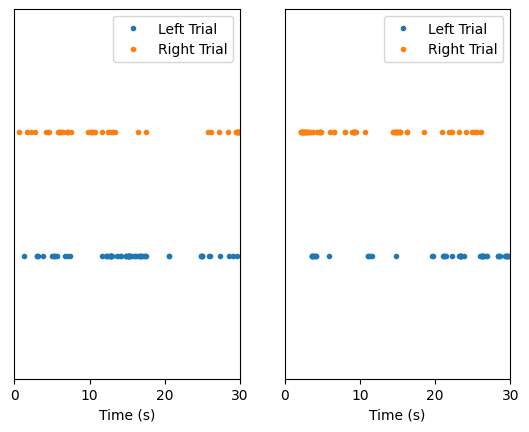

In [73]:
# make 2 subplots
fig, ax = plt.subplots(1, 2)

# trial 1 spike train data
ax[0].plot(spikes_left_trial1, np.ones_like(spikes_left_trial1), '.')
ax[0].plot(spikes_right_trial1, 2 * np.ones_like(spikes_right_trial1), '.')

# trial 2 spike train data
ax[1].plot(spikes_left_trial2, np.ones_like(spikes_left_trial2), '.')
ax[1].plot(spikes_right_trial2, 2 * np.ones_like(spikes_right_trial2), '.')

# label the x axis, remove the y ticks, set x/y axis limits, create legends
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[0].set_yticks([])
ax[1].set_yticks([])
ax[0].set_ylim([0, 3])
ax[1].set_ylim([0, 3])
ax[0].legend({'Left Trial', 'Right Trial'})
ax[1].legend({'Left Trial', 'Right Trial'})

ax[0].set_xlim([0, 30])
ax[1].set_xlim([0, 30])

The neuron seems more bursty during the right turn trials. In both of the plots, the right turn trial spikes (orange) seem more clustered and less evenly distributed or regular compared to the spikes that occurred during the left turn trials.

In [74]:
# calculate ISIs for each spike arrays

isis_left1 = np.diff(spikes_left_trial1)
isis_left2 = np.diff(spikes_left_trial2)
isis_right1 = np.diff(spikes_right_trial1)
isis_right2 = np.diff(spikes_right_trial2)

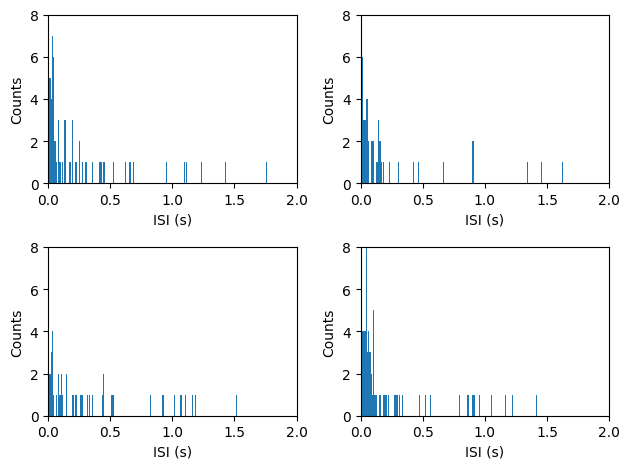

In [75]:
# make histograms for isi arrays
fig, ax = plt.subplots(2, 2)
bins = np.arange(0, 2 + 0.01, 0.01)

# isi left trial 1
ax[0,0].hist(isis_left1, bins)

# isi left trial 2
ax[0,1].hist(isis_left2, bins)

# isi right trial 1
ax[1,0].hist(isis_right1, bins)

# isi right trial 2
ax[1,1].hist(isis_right2, bins)

# set labels and limits for all plots

ax[0,0].set_xlim([0, 2])
ax[0,0].set_ylim([0, 8])
ax[0,0].set_xlabel('ISI (s)')
ax[0,0].set_ylabel('Counts')

ax[0,1].set_xlim([0, 2])
ax[0,1].set_ylim([0, 8])
ax[0,1].set_xlabel('ISI (s)')
ax[0,1].set_ylabel('Counts')

ax[1,0].set_xlim([0, 2])
ax[1,0].set_ylim([0, 8])
ax[1,0].set_xlabel('ISI (s)')
ax[1,0].set_ylabel('Counts')

ax[1,1].set_xlim([0, 2])
ax[1,1].set_ylim([0, 8])
ax[1,1].set_xlabel('ISI (s)')
ax[1,1].set_ylabel('Counts')

# fix formatting
plt.tight_layout()

The neuron seems to fire in bursts, as indicated by the high frequency of shorter ISIs and a few irregularly long pauses between spikes. The neuron still seems to be more bursty during right turn trials, as seen in the bottom right histogram that corresponds to right turn trial 2, which seems to have smaller ISIs than the left turn trials on average and sporadically has longer pauses between spikes.

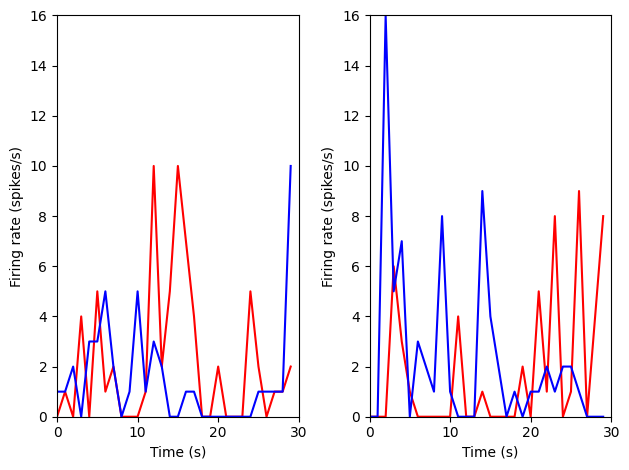

In [98]:
# make 2 subplots
fig, ax = plt.subplots(1, 2)
bins = np.arange(0, 31, 1)

# count the spikes per second for each array and store in var
t1_left_counts, edges = np.histogram(spikes_left_trial1, bins=bins)
t1_right_counts, edges = np.histogram(spikes_right_trial1, bins=bins)
t2_left_counts, edges = np.histogram(spikes_left_trial2, bins=bins)
t2_right_counts, edges = np.histogram(spikes_right_trial2, bins=bins)

# trial 1 time vs. firing rate (spikes)
ax[0].plot(bins[:30], t1_right_counts, color='blue')

# trial 2 time vs. firing rate (spikes)
ax[1].plot(bins[:30], t2_left_counts, color='red')
ax[1].plot(bins[:30], t2_right_counts, color='blue')

# label the x axis, set y axis label, set x/y axis limits, create legends
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('Firing rate (spikes/s)')
ax[1].set_ylabel('Firing rate (spikes/s)')
ax[0].set_ylim([0, 16])
ax[1].set_ylim([0, 16])
ax[0].set_xlim([0, 30])
ax[1].set_xlim([0, 30])

plt.tight_layout()

The firing rate between left and right turn trials seems to differ during the 30s waiting period. For trial 1, the greatest firing rate during the left-turn trial was around the 15 second mark. The firing rate for the left turn trial was generally greater than for the right turn trial except for at the very end. For trial 2, the firing rate was greatest for the right turn trials up until the 15 second mark. After 15 seconds, the firing rate was greater for the left turn trial. The pattern is also different between trials. The firing rate was greater overall for right turn trial 2 compared to right turn trial 1. The firing rate for left turn trials did not seem to differ that much.